In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as con
from scipy.special import erf, erfi
from numpy import sqrt, pi, exp
import scipy

# 23/03/2025

In [2]:
def speed(v):
    return sqrt(np.sum(v**2))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc
    

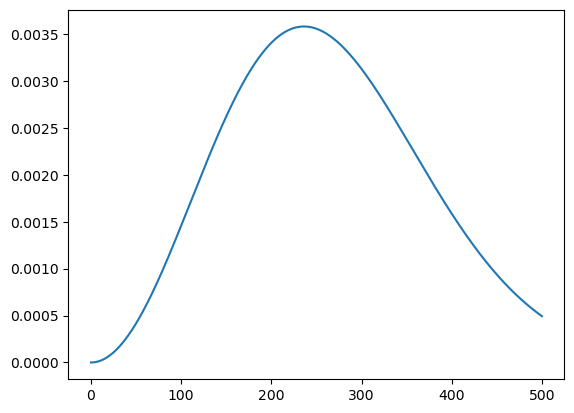

In [123]:
# example of single gaussian/stream

plt.clf()
v = np.linspace(0, 500, 10000)
sig = 167
f = speedDistGaussian(v, sig, 1)
plt.plot(v, f)

In [4]:
def streamN(v):
    sigg = 2.58
    sige = 5.6
    c_0 = 1.1
    f1 = exp(-0.5 * v**2 / sigg**2)
    f2 = c_0 * exp(- np.abs(v) / sige)
    return f1+f2

<Figure size 640x480 with 0 Axes>

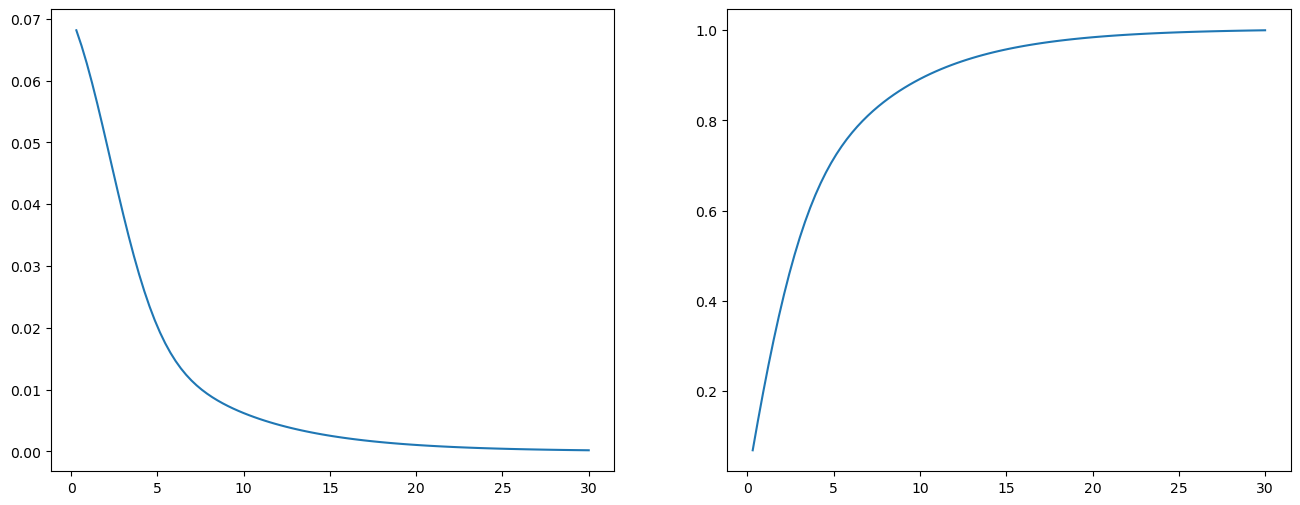

In [22]:
#from https://iopscience.iop.org/article/10.3847/1538-4357/ad7b35
#using random constant values for now
# this is just a placeholder to find a value for N_str, i didn't read thru the full paper
# the paper produces the plots below based on radial velocity?

v = np.linspace(0, 30, 100)[1:] # the paper goes from -20 to 20, \
    #however we don't care the direction only the speed of the stream
    # maybe need to change the maximum velocity??
y = streamN(v) / np.sum(streamN(v))
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].plot(v, y)
ax[1].plot(v, y.cumsum())

v_str = np.column_stack((v, y))
#np.random.seed(0)
#v_str = np.random.choice(a=v, p=y, size = 1000)



In [ ]:
np.random.seed(0)
v_strs = np.random.choice(a=v, p=y, size = 10000)
y = streamN(v_strs)
y = y / np.sum(y)
v_str = np.column_stack((v_strs, y))

In [25]:
v = np.linspace(0, 30, 1000)[1:]

f = []
sig = 0.005
for i in v_str:
    v_c = i[0]
    p = i[1]
    f.append(p* speedDistGaussian(v, sig, v_c))

f = np.array(f)

<Figure size 640x480 with 0 Axes>

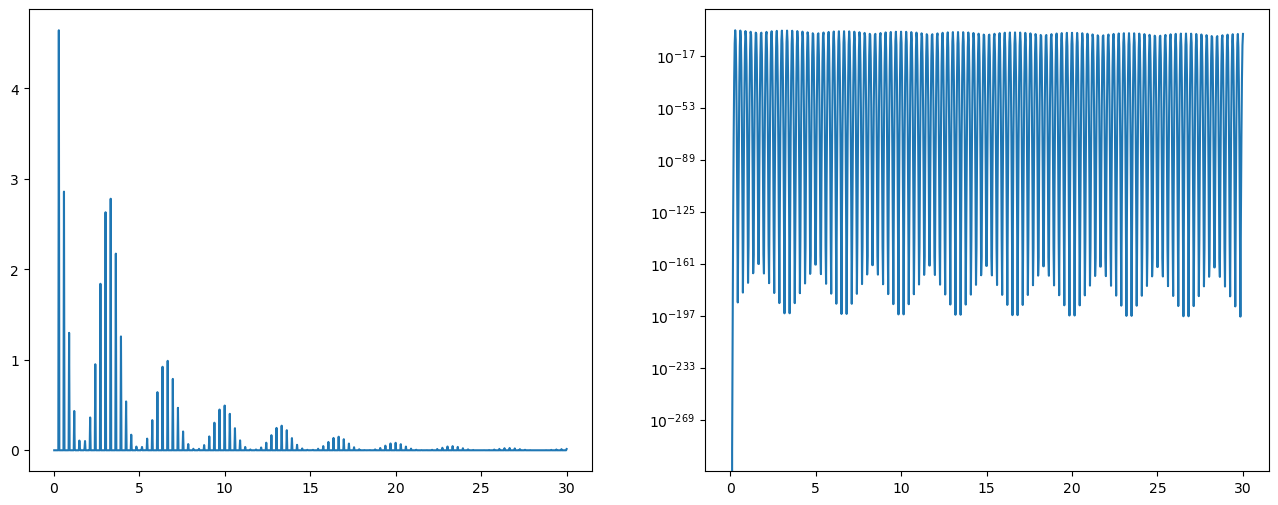

In [26]:
plt.clf()
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].plot(v, f.sum(axis=0))
ax[1].semilogy(v, f.sum(axis=0))

In [47]:
v_str[:, 0]

array([3.12663127, 4.99414994, 3.61773618, ..., 5.74715747, 0.10680107,
       7.03447034], shape=(10000,))

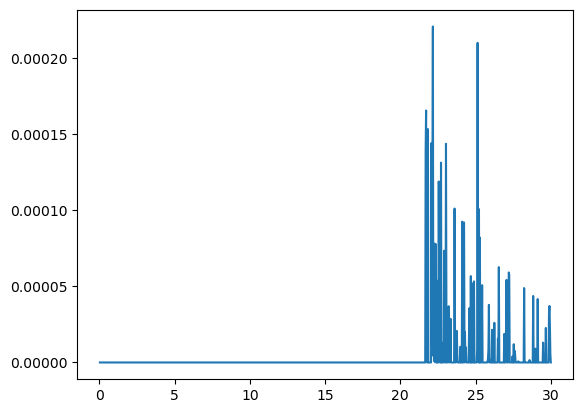

In [79]:
plt.clf()
plt.plot(v, f[np.argsort(v_str[:, 0])][::-1][:100].sum(axis=0))

In [57]:
np.argsort(v_str[:, 0])[::-1]

array([8163, 2749, 5081, ..., 7648, 3856, 2055], shape=(10000,))

In [69]:
f[np.argsort(v_str[:, 0])][::-1][:50].sum(axis=0)

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0

In [ ]:
# random.multivariate_normal, centred on (0, 0, 0), covariance is diagonal (dispersion of halo squared ~167)
# look at fine gained structured for rho/M
# velocity of streams 
# phase mixing

# for traferring to signal use A.2 in fine grained
# quality factor q = w_0 / delta w = m_a / m_a / v^2

# 25th to 31st March
## Feedback:
- Better to sample stream velocities from the halo's gaussian distribution. Easy to do this, just use random.multivariate_normal, centred on (0, 0, 0), covariance is diagonal (dispersion of halo squared ~167)
- Each stream should have a different density as well. Specifically we use, f (ρ) = scipy.stats.skewnorm.pdf(log(rho),-2.10,loc=-11.37,scale=7.15)/rho, as shown in Ciaran's Fine-grained dark matter paper
- Look at phase mixing, it tells us about velocity of streams/ how the streams came to be (folds etc.) (optional for now)
- After making a proper model/distribution, look into extracting/transforming it into a signal (A.2. in fine grained.) quality factor q = w_0 / delta w = m_a / m_a / v^2


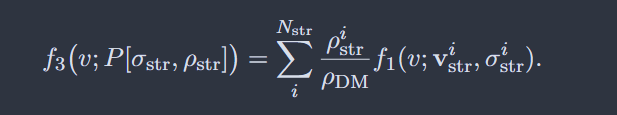

In [28]:
def speed(v):
    return sqrt(np.sum(v**2, axis = 1))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc

In [58]:
def fun(rho, str_num):
    return np.abs(scipy.stats.skewnorm.pdf(np.log(rho),-2.10,loc=-11.37,scale=7.15)/rho - str_num)

def get_density(str_num):
    # returns the optimum stream density to get 
    return scipy.optimize.minimize(fun, x0 = 2.04e-3, bounds = [(7.7e-8, np.inf)], args=[str_num]).x[0]

v_c = np.array([[218, -119, 21]]) # just set it to 1 cause v_c = 0 breaks the function
# 8th march

num = 1000
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167]*3), num)
spd = speed(vel + v_c)

rho = []
for str_num in range(1, num+1):
    rho.append(get_density(str_num))

streams = np.column_stack([spd, rho])


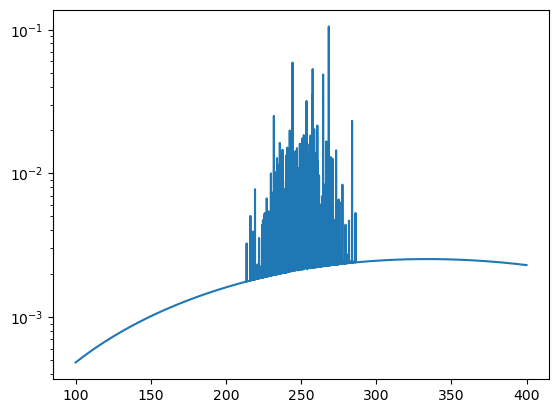

In [60]:
plt.clf()
deltas = []
sig = 0.01 # ask ciaran what do to about the dispersion velocities
v = np.linspace(100, 400, 5000)
for v_e, p in streams:
    gauss = p * speedDistGaussian(v, sig, v_e)
    deltas.append(gauss)

perturb = np.sum(deltas, axis = 0)
total = speedDistGaussian(v, 167, speed(v_c)) * (1 - np.sum(rho)) + perturb

plt.semilogy(v, total)

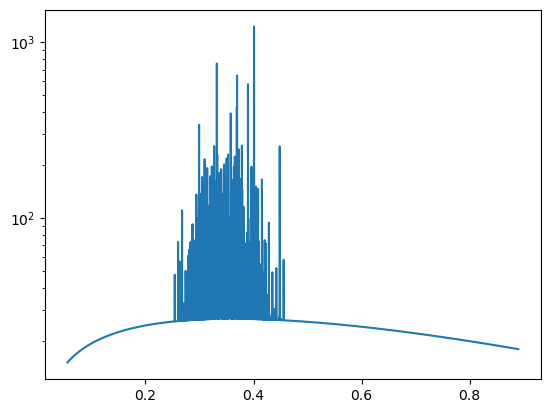

In [62]:
m_a = 1e-6 # in eV
lineshape = np.pi * total / (m_a *v) # T -> infty

w = (v*v/con.c / con.c *1e6 + 2)*m_a / 2
plt.clf()
plt.semilogy((w/m_a - 1) * 1e6, lineshape)

In [183]:
# CONVERT IT FOR LOCAL SUN

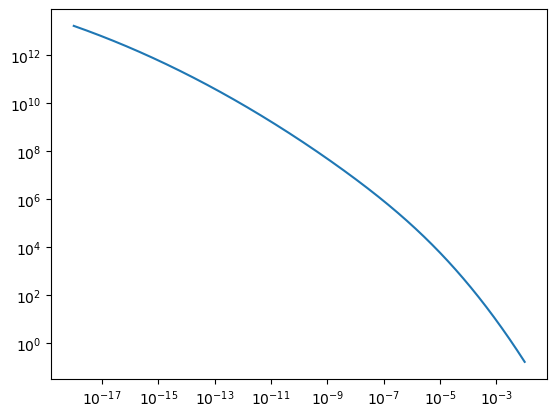

In [38]:
rho = np.logspace(-18, -2, 1000)
f = scipy.stats.skewnorm.pdf(np.log(rho),-2.10,loc=-11.37,scale=7.15)/rho
plt.clf()
plt.loglog(rho, f)

# 15th April -

In [2]:
def speed(v):
    return sqrt(np.sum(v**2, axis = 1))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc

In [6]:
v_c = np.array([12.9, 245.6, 7.78])# + np.array([100, -50 ,0 ])# just set it to 1 cause v_c = 0 breaks the function
# 8th march

num = 10000
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167**2]*3), num) 

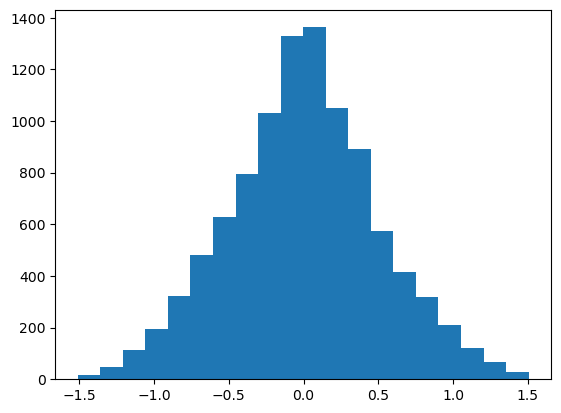

In [58]:
vel += v_c

cost = vel[:, 2] / speed(vel)
phi = np.arctan(vel[:, 1] / vel[:, 0])
omega = cost*phi
plt.hist(omega, 20)

vel -= v_c

# so this changes according to v_c, i.e. it centres around v_c

In [80]:
import astropy.constants as acon

def grav(x):
    return - acon.G.value * 1e-9 * acon.M_sun.value / 149600000

vel += v_c

def v_inf(v):
    r = -np.array([v_c]) * np.array([[1, 1, 1]]) # in km
    d = np.sqrt(np.sum(v*v) + 2 * grav(r))

    vi = d * d * v \
        -  d * r / speed(r) * grav(r) \
        - d * v * (np.dot(v, r.T / speed(r)))
    
    vi = vi / (d*d - grav(r) - d * np.dot(v, r.T / speed(r)))
    
    return vi

vel -= v_c

In [81]:
from scipy.optimize import fsolve

def func(v, vi):
    return (v_inf(v) - vi).T[:, 0]

vel += v_c

v = []
for vi in vel:
    root = fsolve(func, [25,25, 25], args=(vi,))
    v.append(root)
v = np.array(v)
vel -= v_c
v

/tmp/ipykernel_605/2744102655.py:10: RuntimeWarning: invalid value encountered in sqrt
  d = np.sqrt(np.sum(v*v) + 2 * grav(r))
/tmp/ipykernel_605/3718266857.py:10: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [25,25, 25], args=(vi,))


array([[ 308.27370478,  314.25577967,  171.66456362],
       [ 387.55436344,  558.73927694, -155.55930951],
       [ 172.7214028 ,  223.424081  ,   -9.46142006],
       ...,
       [ 187.31282008,  267.87051896, -120.02841763],
       [ 115.28563174,  182.43677128,  -90.75714651],
       [-239.87339264,  410.44176356,  217.87890827]])

In [82]:
mask = np.floor(np.sum(v != [-25, 25, -25], axis = 1)/3).astype(bool)
v = v[mask]
mask.sum()

9983

(array([9.100e+01, 3.160e+02, 5.660e+02, 8.710e+02, 1.076e+03, 1.263e+03,
        1.310e+03, 1.206e+03, 1.038e+03, 8.230e+02, 5.860e+02, 3.590e+02,
        2.420e+02, 1.190e+02, 6.800e+01, 3.200e+01, 1.000e+01, 5.000e+00,
        1.000e+00, 1.000e+00]),
 array([ 42.8229833 ,  88.96860962, 135.11423593, 181.25986224,
        227.40548856, 273.55111487, 319.69674118, 365.8423675 ,
        411.98799381, 458.13362012, 504.27924644, 550.42487275,
        596.57049906, 642.71612538, 688.86175169, 735.007378  ,
        781.15300432, 827.29863063, 873.44425694, 919.58988326,
        965.73550957]),
 <BarContainer object of 20 artists>)

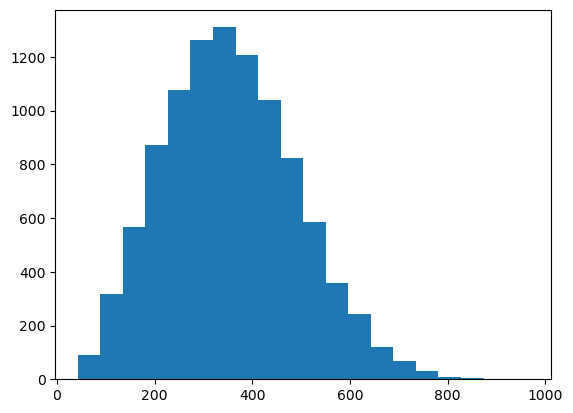

In [83]:
vh = [v[i] / speed(np.array([v[i]])) for i in range(len(v))]
vh = np.array(vh)
plt.hist(speed(v), 20)

(array([  19.,   50.,  114.,  201.,  327.,  487.,  640.,  796., 1053.,
        1397., 1308., 1038.,  887.,  544.,  413.,  298.,  207.,  118.,
          64.,   22.]),
 array([-1.50837836, -1.35678481, -1.20519125, -1.0535977 , -0.90200415,
        -0.75041059, -0.59881704, -0.44722349, -0.29562993, -0.14403638,
         0.00755717,  0.15915073,  0.31074428,  0.46233783,  0.61393139,
         0.76552494,  0.91711849,  1.06871205,  1.2203056 ,  1.37189915,
         1.52349271]),
 <BarContainer object of 20 artists>)

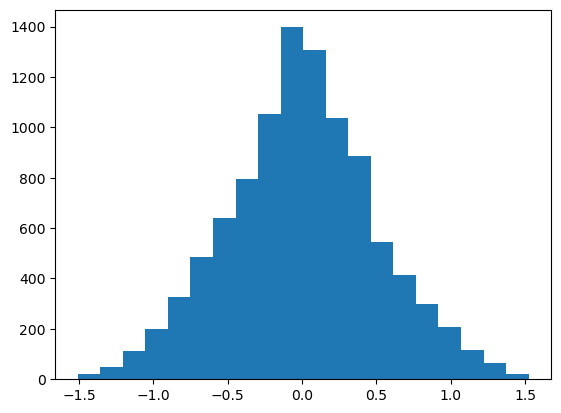

In [84]:
cost1 = v[:, 2] / speed(v)
phi1 = np.arctan(v[:, 1] / v[:, 0])
omega1 = cost1*phi1
plt.hist(omega1, 20)

array([  0.,   7.,  37.,  70., 108., 159., 187., 245., 307., 366., 396.,
       419., 469., 512., 527., 555., 558., 535., 529., 499., 457., 451.,
       421., 364., 332., 283., 234., 182., 168., 133., 110., 103.,  59.,
        59.,  35.,  33.,  23.,  16.,  13.,   6.,   9.,   0.,   5.,   0.,
         0.,   1.,   0.,   0.,   1.])

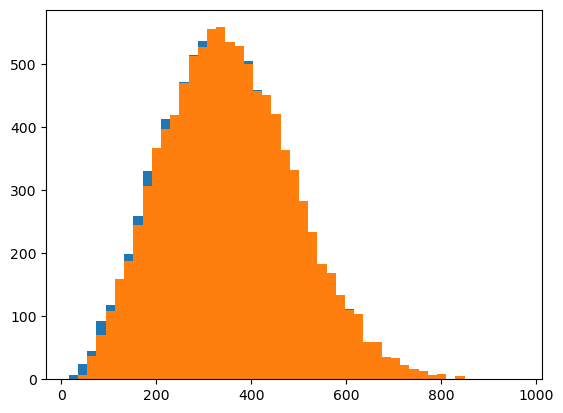

In [96]:
plt.clf()

dist_i = speed(vel + v_c) #omega
dist_f = speed(v) #omega1

bins = np.linspace(min(np.min(dist_i), np.min(dist_f)), max(np.max(dist_i), np.max(dist_f)), 50)
plt.hist(dist_i, bins)[0]
plt.hist(dist_f, bins)[0]

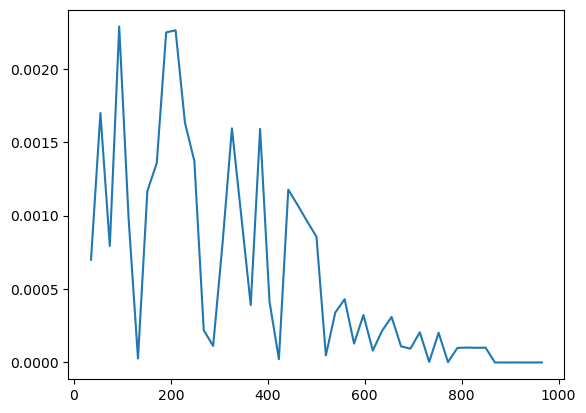

In [97]:
y = plt.hist(dist_i, bins)[0] * np.sum(mask)/10000 - plt.hist(dist_f, bins)[0]
plt.clf()
plt.plot(bins[1:], np.abs(y) / np.sum(mask))

array([ 0.,  1.,  3.,  2.,  4., -6.,  8.,  5., -2.,  0.,  4.,  4., -3.,
        6., -3.,  4., -3.,  0.,  2.,  5., -4.,  2., -2., -1., -1.,  0.,
       -2., -4.,  4., -6.,  4., -1., -5., -2.,  3., -1.,  0.,  3.,  0.,
       -9.,  2.,  5., -3.,  8., -8.,  2.,  6., -9.,  5.])

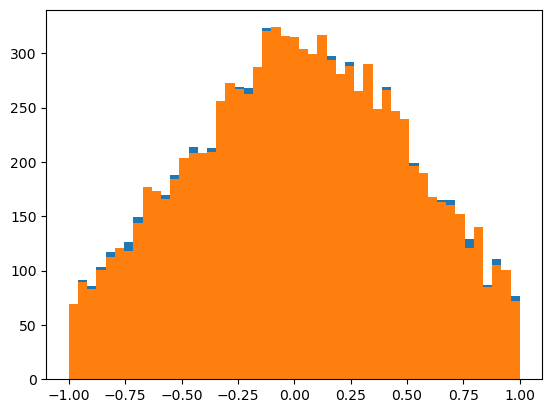

In [90]:
plt.clf()

dist_i = cost
dist_f = cost1

bins = np.linspace(min(np.min(dist_i), np.min(dist_f)), max(np.max(dist_i), np.max(dist_f)), 50)
plt.hist(dist_i, bins)[0] - plt.hist(dist_f, bins)[0]

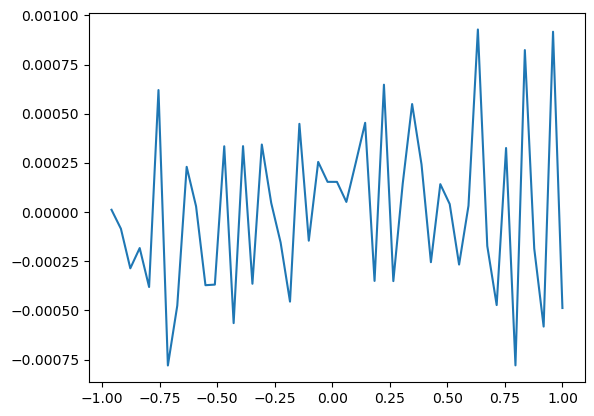

In [91]:
y = plt.hist(dist_i, bins)[0] * np.sum(mask)/10000 - plt.hist(dist_f, bins)[0]
plt.clf()
plt.plot(bins[1:], -y / np.sum(mask))

In [56]:
bins[np.argmax(-y)], np.mean(omega)

(0.5151207583503234, 0.0007806766730814431)

In [57]:
np.mean(omega1)

-0.019903247256983683

In [ ]:
# plot a 2d histogram of costheta, phi (difference between f_gf and f)
# use str vels i picked out to make a new distribution with stream densities and plot a 2d histogram of that
# keep the derivative of a delta function.